In [39]:
from imutils import paths
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from random import shuffle
import random
import timeit

from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.utils import class_weight

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import AveragePooling2D, Dropout, Flatten, Dense, Input, BatchNormalization
from tensorflow.keras.models import Model, model_from_json
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import losses
from tensorflow.keras import datasets, layers, models
import tensorflow as tf

import tensorflow_addons as tfa

from tensorflow.keras.applications import imagenet_utils
from tensorflow.keras.applications.xception import decode_predictions

In [1]:
from pyFile import ARModel
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession
import numpy as np

import matplotlib.pyplot as plt

2022-10-27 11:23:16.432758: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1


In [2]:
modelAvl = ["vgg16","vgg19","inception","xception","resnet50","resnet101","densenet","inceptionResnet"]
modelSel = ["inception", "xception" ]
modelOnly = ["xception"]
losses = ["bce", "cce", "focal", "kld"]
lossSel = ["bce", "focal"]
lossOnly = ["focal"]

In [3]:
def fix_gpu():
    config = ConfigProto()
    config.gpu_options.allow_growth = True
    session = InteractiveSession(config=config)

fix_gpu()

2022-10-27 11:25:29.179030: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-10-27 11:25:29.182025: I tensorflow/compiler/jit/xla_gpu_device.cc:99] Not creating XLA devices, tf_xla_enable_xla_devices not set
2022-10-27 11:25:29.182720: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2022-10-27 11:25:29.250854: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:941] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-10-27 11:25:29.251046: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:01:00.0 na

In [4]:
model = ARModel()

In [28]:
(data, labels) = model.loadImages(r'/home/bishal/Research/Allergic-Rhinitis/Dataset/all/rotate', 
        plotType="R", classification="multiclass", colorMode="RGB", cleanImageF=True, resize=True,
        correctColor=False, contours=False, crop=True ,printImgDemo=False)

[INFO]: Trying to Read the images from  /home/bishal/Research/Allergic-Rhinitis/Dataset/all/rotate
Images found : 90


In [29]:
(data, labels) = model.prepareData(data, labels, weightedLossCalc=True)

[INFO]: Preparing Data
{'imgNumber': 111, 'dataInfo': 'R', 'classification': 'multiclass', 'imageCount': 90, 'imageType': 'R', 'classType': 'multiclass', 'colorMode': 'RGB', 'clean': True, 'crop': True, 'resize': True, 'colorCorrect': False, 'imgDim': (224, 224, 3), 'weightedLoss': array([0.68181818, 1.875     , 1.        ]), 'dataAugmentation': {'rotate': 2, 'zoom': 0.15, 'wShift': 0.2, 'hShift': 0.2, 'shear': 0.15, 'hFlip': True, 'vFlip': False}, 'model': 'xception', 'dropoutRate': 0.5, 'activation': 'siren', 'baseTrain': False, 'learningRate': 0.001, 'epochsMax': 200, 'batchSize': 8, 'loss': 'focal', 'callbacks': [<tensorflow.python.keras.callbacks.ModelCheckpoint object at 0x7f6090287f70>, <tensorflow.python.keras.callbacks.EarlyStopping object at 0x7f6090287d60>], 'traingTime': 108.68621812108904, 'earlyStop': True, 'learningDecay': False, 'wloss': True, 'epochs': 200, 'voting': 30}


In [30]:
trainAug = model.setDataAugmentation(normalizeData=False, rotate=2, zoom=0.15, wShift=0.2, hShift=0.2, 
                                shear=0.15, hFlip=True, vFlip=False, generateImages=False)


[INFO]: Augmenting Data with - 
{'rotate': 2, 'zoom': 0.15, 'wShift': 0.2, 'hShift': 0.2, 'shear': 0.15, 'hFlip': True, 'vFlip': False}


Sizes :  (89, 224, 224, 3) -- (89, 3)
Sizes :  (224, 224, 3) -- (3,)


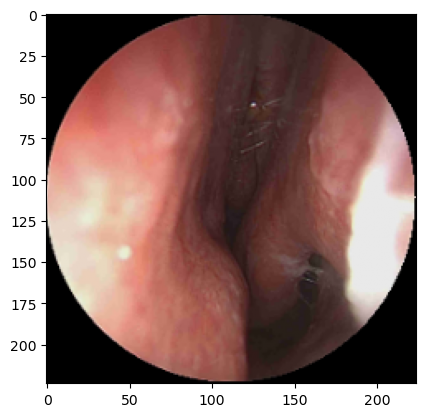

In [31]:
#plt.imshow(trainX[54])

In [32]:
#(trainX, trainY, testX, testY) = model.setPartition(data, labels, testSize=0.20)

[INFO]: Patition Set to -  80:20


In [10]:
#testY = np.expand_dims(testY, 0)
#testX = np.expand_dims(testX, 0)

In [19]:
testY

array([[0, 0, 1]])

In [33]:
testX.shape

(18, 224, 224, 3)

In [34]:
currBModel = model.setBaseModel("xception")
                
currHModel = model.setHeadModel(currBModel, dropoutRate=0.5, activation="siren")
finalModel = model.initModel(currBModel, currHModel, baseTrainable=False)
model.setHyperParameters(learningRate = 1e-3, epochs = 200, batchSize = 8)
finalModel = model.compileModel(finalModel, loss="focal")

[INFO]: Model Selected -  xception
[INFO]: Initializing Model
[INFO]: Hyperparameters Set
[INFO]: Compiling Model


In [48]:
y_hat = []
y = []

In [53]:
for i in range(len(data)):
    trainX = np.delete(data, [i], axis=0)
    trainY = np.delete(labels, [i], axis=0)
    testX = np.expand_dims(data[i], 0)
    testY = np.expand_dims(labels[i], 0)
    y.append(labels[i])
    print("Sizes : ", trainX.shape, "--", trainY.shape)
    print("Sizes : ", testX.shape, "--", testY.shape)
    
    (H, finalModel) = model.startTraining(finalModel, trainAug, trainX, trainY, 
                                            testX, testY, weightedLoss=True, learningDecay=False, earlyStop=True)
    
    predIdxs = model.startTesting(testX, testY, finalModel, voting=0)
    y_hat.append(predIdxs[0])

Sizes :  (89, 224, 224, 3) -- (89, 3)
Sizes :  (1, 224, 224, 3) -- (1, 3)
[INFO] Model Training
Epoch 1/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0568 - accuracy: 0.8889

Epoch 00001: loss improved from inf to 0.05676, saving model to AR_MODEL.hdf5
Epoch 2/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0418 - accuracy: 0.9205

Epoch 00002: loss improved from 0.05676 to 0.04180, saving model to AR_MODEL.hdf5
Epoch 3/200
11/11 [==============================] - 0s 43ms/step - loss: 0.0380 - accuracy: 0.9630

Epoch 00003: loss improved from 0.04180 to 0.03799, saving model to AR_MODEL.hdf5
Epoch 4/200
11/11 [==============================] - 1s 43ms/step - loss: 0.0274 - accuracy: 0.9630

Epoch 00004: loss improved from 0.03799 to 0.02737, saving model to AR_MODEL.hdf5
Epoch 5/200
11/11 [==============================] - 0s 40ms/step - loss: 0.0302 - accuracy: 0.9753

Epoch 00005: loss did not improve from 0.02737
Epoch 6/200
11/11 [=========

11/11 [==============================] - 1s 44ms/step - loss: 0.0532 - accuracy: 0.8750

Epoch 00054: loss did not improve from 0.01886
Epoch 55/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0960 - accuracy: 0.8395

Epoch 00055: loss did not improve from 0.01886
Epoch 56/200
11/11 [==============================] - 0s 43ms/step - loss: 0.0673 - accuracy: 0.8519

Epoch 00056: loss did not improve from 0.01886
Epoch 57/200
11/11 [==============================] - 0s 41ms/step - loss: 0.1109 - accuracy: 0.7901

Epoch 00057: loss did not improve from 0.01886
Epoch 58/200
11/11 [==============================] - 0s 42ms/step - loss: 0.1491 - accuracy: 0.8025

Epoch 00058: loss did not improve from 0.01886
Epoch 59/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0799 - accuracy: 0.8272

Epoch 00059: loss did not improve from 0.01886
Epoch 60/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0533 - accuracy: 0.9012

Epoch 00060: loss

11/11 [==============================] - 0s 40ms/step - loss: 0.0588 - accuracy: 0.9012

Epoch 00109: loss did not improve from 0.01886
Epoch 110/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0732 - accuracy: 0.8295

Epoch 00110: loss did not improve from 0.01886
Epoch 111/200
11/11 [==============================] - 0s 40ms/step - loss: 0.0731 - accuracy: 0.9383

Epoch 00111: loss did not improve from 0.01886
Epoch 112/200
11/11 [==============================] - 0s 44ms/step - loss: 0.0412 - accuracy: 0.9506

Epoch 00112: loss did not improve from 0.01886
Epoch 113/200
11/11 [==============================] - 0s 43ms/step - loss: 0.0578 - accuracy: 0.9136

Epoch 00113: loss did not improve from 0.01886
Epoch 114/200
11/11 [==============================] - 0s 45ms/step - loss: 0.0278 - accuracy: 0.9383

Epoch 00114: loss did not improve from 0.01886
Epoch 115/200
11/11 [==============================] - 1s 45ms/step - loss: 0.0570 - accuracy: 0.9318

Epoch 00115

11/11 [==============================] - 0s 41ms/step - loss: 0.0652 - accuracy: 0.9012

Epoch 00039: loss did not improve from 0.01922
Epoch 40/200
11/11 [==============================] - 0s 40ms/step - loss: 0.0620 - accuracy: 0.8889

Epoch 00040: loss did not improve from 0.01922
Epoch 41/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0803 - accuracy: 0.9012

Epoch 00041: loss did not improve from 0.01922
Epoch 42/200
11/11 [==============================] - 0s 43ms/step - loss: 0.0834 - accuracy: 0.8864

Epoch 00042: loss did not improve from 0.01922
Epoch 43/200
11/11 [==============================] - 0s 41ms/step - loss: 0.1026 - accuracy: 0.8395

Epoch 00043: loss did not improve from 0.01922
Epoch 44/200
11/11 [==============================] - 0s 39ms/step - loss: 0.0648 - accuracy: 0.8765

Epoch 00044: loss did not improve from 0.01922
Epoch 45/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0561 - accuracy: 0.8864

Epoch 00045: loss

11/11 [==============================] - 0s 41ms/step - loss: 0.0643 - accuracy: 0.8395

Epoch 00094: loss did not improve from 0.01922
Epoch 95/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0921 - accuracy: 0.8395

Epoch 00095: loss did not improve from 0.01922
Epoch 96/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0632 - accuracy: 0.8889

Epoch 00096: loss did not improve from 0.01922
Epoch 97/200
11/11 [==============================] - 0s 40ms/step - loss: 0.0711 - accuracy: 0.8642

Epoch 00097: loss did not improve from 0.01922
Epoch 98/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0558 - accuracy: 0.9318

Epoch 00098: loss did not improve from 0.01922
Epoch 99/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0484 - accuracy: 0.9259

Epoch 00099: loss did not improve from 0.01922
Epoch 100/200
11/11 [==============================] - 0s 39ms/step - loss: 0.0550 - accuracy: 0.9012

Epoch 00100: los

...

11/11 [==============================] - 0s 46ms/step - loss: 0.0674 - accuracy: 0.8148

Epoch 00059: loss did not improve from 0.01593
Epoch 60/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0294 - accuracy: 0.9506

Epoch 00060: loss did not improve from 0.01593
Epoch 61/200
11/11 [==============================] - 1s 44ms/step - loss: 0.0339 - accuracy: 0.9432

Epoch 00061: loss did not improve from 0.01593
Epoch 62/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0250 - accuracy: 0.9136

Epoch 00062: loss did not improve from 0.01593
Epoch 63/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0275 - accuracy: 0.9012

Epoch 00063: loss did not improve from 0.01593
Epoch 64/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0253 - accuracy: 0.9136

Epoch 00064: loss did not improve from 0.01593
Epoch 65/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0147 - accuracy: 0.9753

Epoch 00065: loss

11/11 [==============================] - 0s 41ms/step - loss: 0.0297 - accuracy: 0.9506

Epoch 00114: loss did not improve from 0.01470
Epoch 115/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0320 - accuracy: 0.9383

Epoch 00115: loss did not improve from 0.01470
Epoch 116/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0351 - accuracy: 0.9506

Epoch 00116: loss did not improve from 0.01470
Epoch 117/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0299 - accuracy: 0.9012

Epoch 00117: loss did not improve from 0.01470
Epoch 118/200
11/11 [==============================] - 1s 45ms/step - loss: 0.0286 - accuracy: 0.9205

Epoch 00118: loss did not improve from 0.01470
Epoch 119/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0497 - accuracy: 0.8765

Epoch 00119: loss did not improve from 0.01470
Epoch 120/200
11/11 [==============================] - 1s 43ms/step - loss: 0.0314 - accuracy: 0.9259

Epoch 00120

11/11 [==============================] - 1s 45ms/step - loss: 0.0204 - accuracy: 0.9318

Epoch 00168: loss did not improve from 0.01374
Epoch 169/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0382 - accuracy: 0.8889

Epoch 00169: loss did not improve from 0.01374
Epoch 170/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0178 - accuracy: 0.9753

Epoch 00170: loss did not improve from 0.01374
Epoch 171/200
11/11 [==============================] - 0s 43ms/step - loss: 0.0367 - accuracy: 0.9091

Epoch 00171: loss did not improve from 0.01374
Epoch 172/200
11/11 [==============================] - 0s 43ms/step - loss: 0.0397 - accuracy: 0.8889

Epoch 00172: loss did not improve from 0.01374
Epoch 173/200
11/11 [==============================] - 0s 42ms/step - loss: 0.1342 - accuracy: 0.7901

Epoch 00173: loss did not improve from 0.01374
Epoch 174/200
11/11 [==============================] - 0s 42ms/step - loss: 0.1047 - accuracy: 0.8395

Epoch 00174

11/11 [==============================] - 1s 44ms/step - loss: 0.0511 - accuracy: 0.9205

Epoch 00021: loss did not improve from 0.02501
Epoch 22/200
11/11 [==============================] - 1s 43ms/step - loss: 0.0482 - accuracy: 0.9091

Epoch 00022: loss did not improve from 0.02501
Epoch 23/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0507 - accuracy: 0.8519

Epoch 00023: loss did not improve from 0.02501
Epoch 24/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0555 - accuracy: 0.8519

Epoch 00024: loss did not improve from 0.02501
Epoch 25/200
11/11 [==============================] - 1s 44ms/step - loss: 0.0653 - accuracy: 0.8409

Epoch 00025: loss did not improve from 0.02501
Epoch 26/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0539 - accuracy: 0.8765

Epoch 00026: loss did not improve from 0.02501
Epoch 27/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0570 - accuracy: 0.8025

Epoch 00027: loss

11/11 [==============================] - 0s 41ms/step - loss: 0.1099 - accuracy: 0.8025

Epoch 00075: loss did not improve from 0.02274
Epoch 76/200
11/11 [==============================] - 0s 44ms/step - loss: 0.0651 - accuracy: 0.8889

Epoch 00076: loss did not improve from 0.02274
Epoch 77/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0835 - accuracy: 0.8272

Epoch 00077: loss did not improve from 0.02274
Epoch 78/200
11/11 [==============================] - 1s 43ms/step - loss: 0.1022 - accuracy: 0.8642

Epoch 00078: loss did not improve from 0.02274
Epoch 79/200
11/11 [==============================] - 0s 40ms/step - loss: 0.0648 - accuracy: 0.8148

Epoch 00079: loss did not improve from 0.02274
Epoch 80/200
11/11 [==============================] - 1s 44ms/step - loss: 0.0572 - accuracy: 0.8765

Epoch 00080: loss did not improve from 0.02274
Epoch 81/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0555 - accuracy: 0.8395

Epoch 00081: loss

In [54]:
y_hat

[1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 2,
 2,
 2,
 2,
 2,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 2,
 2,
 2,
 2,
 2,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 2,
 2,
 2,
 2,
 2,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 2,
 2,
 2,
 2,
 2,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 2,
 2,
 2,
 2,
 2]

In [55]:
y

[array([0, 1, 0]),
 array([0, 1, 0]),
 array([0, 1, 0]),
 array([0, 1, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([0, 0, 1]),
 array([0, 0, 1]),
 array([0, 0, 1]),
 array([0, 0, 1]),
 array([0, 0, 1]),
 array([0, 0, 1]),
 array([0, 1, 0]),
 array([0, 1, 0]),
 array([0, 1, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([0, 0, 1]),
 array([0, 0, 1]),
 array([0, 0, 1]),
 array([0, 0, 1]),
 array([0, 0, 1]),
 array([0, 0, 1]),
 array([0, 1, 0]),
 array([0, 1, 0]),
 array([0, 1, 0]),
 array([0, 1, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([1, 0, 0]),
 array([0, 0, 1]),
 array([0, 0, 1]),
 array([0, 0, 1]),
 array([0, 0

In [63]:
y_org = []
for val in y:
    if val[0]:
        y_org.append(0)
    elif val[1]:
        y_org.append(1)
    elif val[2]:
        y_org.append(2)

In [67]:
len(y_org)

91

In [64]:
count = 0
for val in y_org:
    

[1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 2,
 2,
 2,
 2,
 2,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 2,
 2,
 2,
 2,
 2,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 2,
 2,
 2,
 2,
 2,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 2,
 2,
 2,
 2,
 2,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 2,
 2,
 2,
 2,
 2]

In [58]:
y_ = np.array(y)
y_hat_ = np.array(y_hat)

In [35]:
(H, finalModel) = model.startTraining(finalModel, trainAug, trainX, trainY, 
                                                    testX, testY, weightedLoss=True, learningDecay=False, earlyStop=True)

[INFO] Model Training
Epoch 1/200
9/9 [==============================] - 2s 116ms/step - loss: 0.4698 - accuracy: 0.4172 - val_loss: 0.3500 - val_accuracy: 0.1667

Epoch 00001: loss improved from inf to 0.54186, saving model to AR_MODEL.hdf5
Epoch 2/200
9/9 [==============================] - 0s 48ms/step - loss: 0.4360 - accuracy: 0.3760 - val_loss: 0.2164 - val_accuracy: 0.3889

Epoch 00002: loss improved from 0.54186 to 0.42188, saving model to AR_MODEL.hdf5
Epoch 3/200
9/9 [==============================] - 0s 49ms/step - loss: 0.4289 - accuracy: 0.4300 - val_loss: 0.1942 - val_accuracy: 0.5556

Epoch 00003: loss did not improve from 0.42188
Epoch 4/200
9/9 [==============================] - 0s 48ms/step - loss: 0.4469 - accuracy: 0.4190 - val_loss: 0.3058 - val_accuracy: 0.5000

Epoch 00004: loss did not improve from 0.42188
Epoch 5/200
9/9 [==============================] - 0s 50ms/step - loss: 0.5089 - accuracy: 0.4140 - val_loss: 0.1551 - val_accuracy: 0.6667

Epoch 00005: loss 

9/9 [==============================] - 0s 50ms/step - loss: 0.1265 - accuracy: 0.7552 - val_loss: 0.1623 - val_accuracy: 0.7222

Epoch 00042: loss did not improve from 0.10983
Epoch 43/200
9/9 [==============================] - 0s 48ms/step - loss: 0.1108 - accuracy: 0.8353 - val_loss: 0.1609 - val_accuracy: 0.6667

Epoch 00043: loss did not improve from 0.10983
Epoch 44/200
9/9 [==============================] - 0s 50ms/step - loss: 0.1229 - accuracy: 0.7296 - val_loss: 0.1203 - val_accuracy: 0.7778

Epoch 00044: loss did not improve from 0.10983
Epoch 45/200
9/9 [==============================] - 0s 47ms/step - loss: 0.1058 - accuracy: 0.7591 - val_loss: 0.1115 - val_accuracy: 0.7222

Epoch 00045: loss improved from 0.10983 to 0.10957, saving model to AR_MODEL.hdf5
Epoch 46/200
9/9 [==============================] - 0s 49ms/step - loss: 0.1239 - accuracy: 0.7146 - val_loss: 0.1300 - val_accuracy: 0.6667

Epoch 00046: loss did not improve from 0.10957
Epoch 47/200
9/9 [===============

9/9 [==============================] - 0s 50ms/step - loss: 0.1580 - accuracy: 0.7666 - val_loss: 0.1278 - val_accuracy: 0.7222

Epoch 00084: loss did not improve from 0.04963
Epoch 85/200
9/9 [==============================] - 0s 48ms/step - loss: 0.1558 - accuracy: 0.7505 - val_loss: 0.1010 - val_accuracy: 0.6667

Epoch 00085: loss did not improve from 0.04963
Epoch 86/200
9/9 [==============================] - 0s 47ms/step - loss: 0.0837 - accuracy: 0.8071 - val_loss: 0.1088 - val_accuracy: 0.6667

Epoch 00086: loss did not improve from 0.04963
Epoch 87/200
9/9 [==============================] - 0s 49ms/step - loss: 0.0638 - accuracy: 0.9126 - val_loss: 0.1171 - val_accuracy: 0.7222

Epoch 00087: loss did not improve from 0.04963
Epoch 88/200
9/9 [==============================] - 0s 47ms/step - loss: 0.1032 - accuracy: 0.7979 - val_loss: 0.1089 - val_accuracy: 0.7222

Epoch 00088: loss did not improve from 0.04963
Epoch 89/200
9/9 [==============================] - 0s 48ms/step - l


Epoch 00126: loss did not improve from 0.03283
Epoch 127/200
9/9 [==============================] - 0s 49ms/step - loss: 0.0780 - accuracy: 0.9071 - val_loss: 0.1387 - val_accuracy: 0.6667

Epoch 00127: loss did not improve from 0.03283
Epoch 128/200
9/9 [==============================] - 0s 51ms/step - loss: 0.0340 - accuracy: 0.9228 - val_loss: 0.1251 - val_accuracy: 0.7778

Epoch 00128: loss did not improve from 0.03283
Epoch 129/200
9/9 [==============================] - 0s 49ms/step - loss: 0.0442 - accuracy: 0.9250 - val_loss: 0.1310 - val_accuracy: 0.7222

Epoch 00129: loss did not improve from 0.03283
Epoch 130/200
9/9 [==============================] - 0s 48ms/step - loss: 0.0368 - accuracy: 0.9501 - val_loss: 0.1226 - val_accuracy: 0.7778

Epoch 00130: loss did not improve from 0.03283
Epoch 131/200
9/9 [==============================] - 0s 48ms/step - loss: 0.0488 - accuracy: 0.9061 - val_loss: 0.1494 - val_accuracy: 0.7222

Epoch 00131: loss did not improve from 0.03283
Ep


Epoch 00169: loss did not improve from 0.01929
Epoch 170/200
9/9 [==============================] - 0s 50ms/step - loss: 0.0391 - accuracy: 0.9454 - val_loss: 0.1297 - val_accuracy: 0.7222

Epoch 00170: loss did not improve from 0.01929
Epoch 171/200
9/9 [==============================] - 0s 47ms/step - loss: 0.0507 - accuracy: 0.9292 - val_loss: 0.1533 - val_accuracy: 0.6667

Epoch 00171: loss did not improve from 0.01929
Epoch 172/200
9/9 [==============================] - 0s 49ms/step - loss: 0.0314 - accuracy: 0.9411 - val_loss: 0.1348 - val_accuracy: 0.7222

Epoch 00172: loss did not improve from 0.01929
Epoch 173/200
9/9 [==============================] - 0s 48ms/step - loss: 0.0561 - accuracy: 0.8767 - val_loss: 0.1364 - val_accuracy: 0.7222

Epoch 00173: loss did not improve from 0.01929
Epoch 174/200
9/9 [==============================] - 0s 49ms/step - loss: 0.0357 - accuracy: 0.9576 - val_loss: 0.1426 - val_accuracy: 0.6111

Epoch 00174: loss did not improve from 0.01929
Ep

In [36]:
predIdxs = model.startTesting(testX, testY, finalModel, voting=30)

Making Predictions on the Test Set
[INFO]: Test by Voting Initiated


In [37]:
labels[i]

array([0, 0, 1])

In [38]:
predIdxs

array([0, 0, 0, 2, 2, 0, 0, 1, 2, 0, 1, 0, 0, 0, 0, 2, 0, 1])

In [39]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [59]:
cm= confusion_matrix(y_.argmax(axis=1), y_hat_)
print(cm)
total = sum(sum(cm))
acc = (cm[0,0] + cm[1,1] + cm[2,2]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1] + cm[0,2])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1] + cm[1,2])
specificity2 = cm[2, 2] / (cm[2, 0] + cm[2, 1] + cm[2,2])
specificity = (specificity + specificity2) / 2

ValueError: Found input variables with inconsistent numbers of samples: [91, 90]

In [42]:
testY.shape

(18, 3)

In [43]:
preds = np.expand_dims(predIdxs, 0)

In [62]:
print(classification_report(y_[1:].argmax(axis=1), y_hat_, target_names=['0', '1', '2']))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        44
           1       1.00      0.94      0.97        16
           2       1.00      1.00      1.00        30

    accuracy                           0.99        90
   macro avg       0.99      0.98      0.99        90
weighted avg       0.99      0.99      0.99        90



In [45]:
model.evalModel(predIdxs, testY)

[INFO]: Model Evaluation
Classification Report
              precision    recall  f1-score   support

           0       0.73      0.89      0.80         9
           1       0.33      0.33      0.33         3
           2       0.75      0.50      0.60         6

    accuracy                           0.67        18
   macro avg       0.60      0.57      0.58        18
weighted avg       0.67      0.67      0.66        18

Confusion Matrix and its Derrivatives
[[8 0 1]
 [2 1 0]
 [1 2 3]]
acc: 0.6667
sensitivity: 0.8889
specificity: 0.4167
